In [6]:
import pandas as pd
import numpy as np
from datetime import datetime

# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
cancellation = pd.read_csv("cancellation.csv")
subscription = pd.read_csv("subscription_v2.csv", sep=";")

# ── 2. PRE-MERGE CLEANING (REPLICATING R SLICE_MAX) ─────────────────────────
# Parse dates first to allow sorting
cancellation['expiration_date'] = pd.to_datetime(cancellation['expiration_date'], errors='coerce')
subscription['subscription_cancel_date'] = pd.to_datetime(subscription['subscription_cancel_date'], dayfirst=True, errors='coerce')

# Keep only 1 ID per row (latest date) - This fixes the "keep=first" logic error
cancellation = cancellation.sort_values('expiration_date', ascending=False).drop_duplicates('pseudo_id')
subscription = subscription.sort_values('subscription_cancel_date', ascending=False).drop_duplicates('pseudo_id')

# ── 3. MERGE ─────────────────────────────────────────────────────────────────
df = pd.merge(subscription, cancellation, on="pseudo_id", how="left")

# ── 4. DATE PARSING (STANDARDIZATION) ────────────────────────────────────────
# Convert other columns to datetime
date_cols_dmy = ["first_campaign_day", "last_campaign_day", "usr_created", "birthdate"]
for col in date_cols_dmy:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# ── 5. CHURN LOGIC ───────────────────────────────────────────────────────────
# Churn: expiration is on or before the last campaign day
df['churn'] = 0
mask_churn = (df['expiration_date'].notna()) & (df['expiration_date'] <= df['last_campaign_day'])
df.loc[mask_churn, 'churn'] = 1

# Continued subscription (inverse of churn)
df['continued_subscription'] = 1 - df['churn']

# Early Churn: Continued, but expired within 90 days of campaign end
df['early_churn'] = 0
ninety_days_post = df['last_campaign_day'] + pd.Timedelta(days=90)
mask_early = (df['continued_subscription'] == 1) & \
             (df['expiration_date'].notna()) & \
             (df['expiration_date'] <= ninety_days_post)
df.loc[mask_early, 'early_churn'] = 1

# ── 6. CLEANING & FEATURE ENGINEERING ────────────────────────────────────────
# Drop rows missing critical dates for age/loyalty (Matching R's filter)
df = df.dropna(subset=['birthdate', 'usr_created', 'order_date'])

# Handle Categorical Missing Values (Matching R's fct_na_value_to_level)
df['type'] = df['type'].fillna("Ingen afmelding")
df['reason'] = df['reason'].fillna("Ingen afmelding")
df['koen'] = df['koen'].replace(["", " "], np.nan).fillna("Ikke oplyst")

# Replace missing expiration with "Future" date (Using 2100 to avoid Overflow)
df['expiration_date'] = df['expiration_date'].fillna(pd.Timestamp("2100-01-01"))

# Permissions (Convert "true" string to 1/0)
df['permission_given_order'] = df['permission_given_order'].apply(lambda x: 1 if str(x).lower() == "true" else 0)
df['permission_given_today'] = df['permission_given_today'].apply(lambda x: 1 if str(x).lower() == "true" else 0)

# Derived variables: Age and Kundetid
today = pd.Timestamp.now()
df['age'] = (today - df['birthdate']).dt.days / 365.25
df['kundetid_dage'] = (df['order_date'] - df['usr_created']).dt.days

# Filter invalid kundetid (Matching R's extra sikkerhed)
df = df[df['kundetid_dage'] >= 0]

# Kundetid groups (Equivalent to case_when)
bins = [-np.inf, 7, 30, 180, np.inf]
labels = ["0-7 dage", "8-30 dage", "1-6 måneder", "6+ måneder"]
df['kundetid_gruppe'] = pd.cut(df['kundetid_dage'], bins=bins, labels=labels)

# ── 7. FINAL SELECTION & CASTING ─────────────────────────────────────────────
# Drop raw columns used for features (Matching R's select -cols)
cols_to_drop = ['kundetid_dage', 'order_date', 'birthdate', 'usr_created']
model_data = df.drop(columns=cols_to_drop).copy()

# Cast to 'category' for model efficiency
cat_cols = [
    "churn", "type", "reason", "koen", "kundetid_gruppe",
    "permission_given_order", "permission_given_today",
    "continued_subscription", "early_churn"
]

for col in cat_cols:
    if col in model_data.columns:
        model_data[col] = model_data[col].astype("category")

# ── 8. OUTPUT ────────────────────────────────────────────────────────────────
print("--- Churn Distribution ---")
print(model_data['churn'].value_counts(normalize=True))

print("\n--- Summary ---")
print(f"Total rows in model_data: {len(model_data)}")
print(model_data.info())

--- Churn Distribution ---
churn
0    0.581689
1    0.418311
Name: proportion, dtype: float64

--- Summary ---
Total rows in model_data: 1267
<class 'pandas.core.frame.DataFrame'>
Index: 1267 entries, 0 to 1278
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   pseudo_id                 1267 non-null   object        
 1   account_active_days       1267 non-null   int64         
 2   subscription_cancel_date  1050 non-null   datetime64[ns]
 3   koen                      1267 non-null   category      
 4   order_trackertag          1261 non-null   object        
 5   permission_given_order    1267 non-null   category      
 6   permission_given_today    1267 non-null   category      
 7   previous_subscriptions    1267 non-null   int64         
 8   previous_campaigns        1267 non-null   int64         
 9   previous_trials           1267 non-null   int64         
 10  first_c

In [13]:
# model_01 basislinje model

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

# 1. ALIGNED FEATURES (Removing leakage, adding account_active_days)
target_col = "churn"

# Predictors strictly from your R 'glimpse'
quant_cols = [
    "account_active_days",
    "previous_subscriptions",
    "previous_campaigns",
    "previous_trials",
    "newsletters_before_order",
    "newsletters_after_order",
    "age"
]
cat_cols = ["koen", "kundetid_gruppe"]
dummy_cols = ["permission_given_order", "permission_given_today"]

# 2. BUILD FEATURE MATRIX
y = model_data[target_col].astype(int).values

# One-hot encoding (drop_first=True to match standard practice)
df_dummies = pd.get_dummies(model_data[cat_cols], drop_first=True)

X_df = pd.concat([
    model_data[dummy_cols].astype(float),
    df_dummies.astype(float),
    model_data[quant_cols]
], axis=1)

# 3. SPLIT (80/20)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=42, stratify=y
)

# 4. STANDARDIZE
scaler = StandardScaler()
X_train_arr = X_train_df.copy()
X_test_arr = X_test_df.copy()

X_train_arr[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_arr[quant_cols] = scaler.transform(X_test_df[quant_cols])

# Convert to float32
X_train = X_train_arr.values.astype(np.float32)
X_test = X_test_arr.values.astype(np.float32)

# 5. BUILD MODEL 01
K.clear_session()
tf.random.set_seed(42)

model_01 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
], name="baseline_nn")

model_01.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# 6. TRAINING
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Model 01 (Baseline)...")
history_01 = model_01.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# 7. EVALUATE
metrics_01 = model_01.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*30)
print(f"Model 01 TEST AUC: {metrics_01[2]:.4f}")
print("="*30)


Training Model 01 (Baseline)...
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5457 - auc: 0.5373 - loss: 0.7637 - val_accuracy: 0.5961 - val_auc: 0.6949 - val_loss: 0.7143
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6185 - auc: 0.6196 - loss: 0.7236 - val_accuracy: 0.6404 - val_auc: 0.7048 - val_loss: 0.6960
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6148 - auc: 0.6545 - loss: 0.7088 - val_accuracy: 0.6601 - val_auc: 0.7220 - val_loss: 0.6849
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6481 - auc: 0.6813 - loss: 0.6957 - val_accuracy: 0.6502 - val_auc: 0.7280 - val_loss: 0.6775
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6358 - auc: 0.6724 - loss: 0.6934 - val_accuracy: 0.6946 - val_auc: 0.7260 - val_loss: 0.6715
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6556 - auc: 0.7015 - loss: 0.6812 - val_accuracy: 0.6847 - val_auc: 0.7320 - val_loss: 0.6636
Epoch 7/150
2

In [14]:
# model_02 bedre arkitektur

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

# 1. ALIGNED FEATURES (Consistency with R glimpse)
target_col = "churn"
quant_cols = [
    "account_active_days",
    "previous_subscriptions",
    "previous_campaigns",
    "previous_trials",
    "newsletters_before_order",
    "newsletters_after_order",
    "age"
]
cat_cols = ["koen", "kundetid_gruppe"]
dummy_cols = ["permission_given_order", "permission_given_today"]

# 2. BUILD FEATURE MATRIX
y = model_data[target_col].astype(int).values
df_dummies = pd.get_dummies(model_data[cat_cols], drop_first=True)

X_df = pd.concat([
    model_data[dummy_cols].astype(float),
    df_dummies.astype(float),
    model_data[quant_cols]
], axis=1)

# 3. SPLIT
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=42, stratify=y
)

# 4. STANDARDIZE
scaler = StandardScaler()
X_train_arr = X_train_df.copy()
X_test_arr = X_test_df.copy()
X_train_arr[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_arr[quant_cols] = scaler.transform(X_test_df[quant_cols])

X_train = X_train_arr.values.astype(np.float32)
X_test = X_test_arr.values.astype(np.float32)

# 5. BUILD THE DEEP MODEL (Complex Architecture)
K.clear_session()
tf.random.set_seed(42)

model_02 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    # Layer 1: Wide initial layer
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Layer 2: Medium layer
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.Dropout(0.3),

    # Layer 3: Final refinement
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
], name="complex_nn_model")

model_02.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")]
)

# 6. ADVANCED CALLBACKS
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# 7. TRAIN
print("Training Model 02 (Complex NN)...")
history_02 = model_02.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 8. EVALUATE
metrics_02 = model_02.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*40)
print(f"Model 02 TEST AUC:      {metrics_02[2]:.4f}")
print(f"Model 02 TEST RECALL:   {metrics_02[3]:.4f}")
print("="*40)

Training Model 02 (Complex NN)...
Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5654 - auc: 0.5596 - loss: 0.9463 - recall: 0.3959 - val_accuracy: 0.5567 - val_auc: 0.6240 - val_loss: 0.9007 - val_recall: 0.7952 - learning_rate: 0.0010
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5889 - auc: 0.6011 - loss: 0.9006 - recall: 0.4282 - val_accuracy: 0.5419 - val_auc: 0.6342 - val_loss: 0.8983 - val_recall: 0.8193 - learning_rate: 0.0010
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6099 - auc: 0.6279 - loss: 0.8944 - recall: 0.4194 - val_accuracy: 0.5862 - val_auc: 0.6532 - val_loss: 0.8890 - val_recall: 0.6867 - learning_rate: 0.0010
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6272 - auc: 0.6705 - loss: 0.8478 - recall: 0.4604 - val_accuracy: 0.5714 - val_auc: 0.6703 - val_loss: 0.8807 - val_recall: 0.7229 - learning_rate: 0.0010
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6370 - auc: 0.66

In [12]:
# model_03 SMOTE balancering
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# 1. FEATURE SELECTION (Matching your Tidymodels Glimpse Exactly)
target_col = "churn"

# Quantitative columns from your glimpse
quant_cols = [
    "account_active_days",
    "previous_subscriptions",
    "previous_campaigns",
    "previous_trials",
    "newsletters_before_order",
    "newsletters_after_order",
    "age"
]

# Categorical columns from your glimpse
# Note: We drop 'early_churn' because it is a target-related variable, not a predictor
cat_cols = ["koen", "kundetid_gruppe"]
dummy_cols = ["permission_given_order", "permission_given_today"]

# 2. DATA PREPARATION
# Ensure churn is an integer for the NN
y = model_data[target_col].astype(int).values

# One-hot encoding the categories (drop_first=True to avoid the dummy variable trap)
df_dummies = pd.get_dummies(model_data[cat_cols], drop_first=True)

# Combine all features
X_df = pd.concat([
    model_data[dummy_cols].astype(float),
    df_dummies.astype(float),
    model_data[quant_cols]
], axis=1)

# 3. SPLIT
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=42, stratify=y
)

# 4. SCALING & SMOTE
scaler = StandardScaler()
X_train_scaled = X_train_df.copy()
X_test_scaled = X_test_df.copy()

X_train_scaled[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_scaled[quant_cols] = scaler.transform(X_test_df[quant_cols])

# Apply SMOTE to match your Tidymodels 'step_smote'
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# 5. MODEL ARCHITECTURE
model_03 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_consistent_with_R")

model_03.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# 6. TRAINING
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("Training Model 03...")
history_03 = model_03.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 7. EVALUATION
results_03 = model_03.evaluate(X_test_scaled, y_test, verbose=0)
print("\n" + "="*35)
print(f"MODEL 03 (NN) TEST AUC: {results_03[1]:.4f}")
print("="*35)

Training Model 03...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4915 - auc: 0.5117 - loss: 0.7224 - val_accuracy: 0.5236 - val_auc: 0.6132 - val_loss: 0.7056
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5705 - auc: 0.6116 - loss: 0.6942 - val_accuracy: 0.6220 - val_auc: 0.7068 - val_loss: 0.6858
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6239 - auc: 0.6676 - loss: 0.6772 - val_accuracy: 0.6535 - val_auc: 0.7309 - val_loss: 0.6654
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6426 - auc: 0.6987 - loss: 0.6615 - val_accuracy: 0.6929 - val_auc: 0.7472 - val_loss: 0.6484
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6316 - auc: 0.6889 - loss: 0.6567 - val_accuracy: 0.6890 - val_auc: 0.7540 - val_loss: 0.6344
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6460 - auc: 0.7020 - loss: 0.6508 - val_accuracy: 0.6693 - val_auc: 0.7581 - val_loss: 0.6289
Epoch 7/150
37/37 ━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


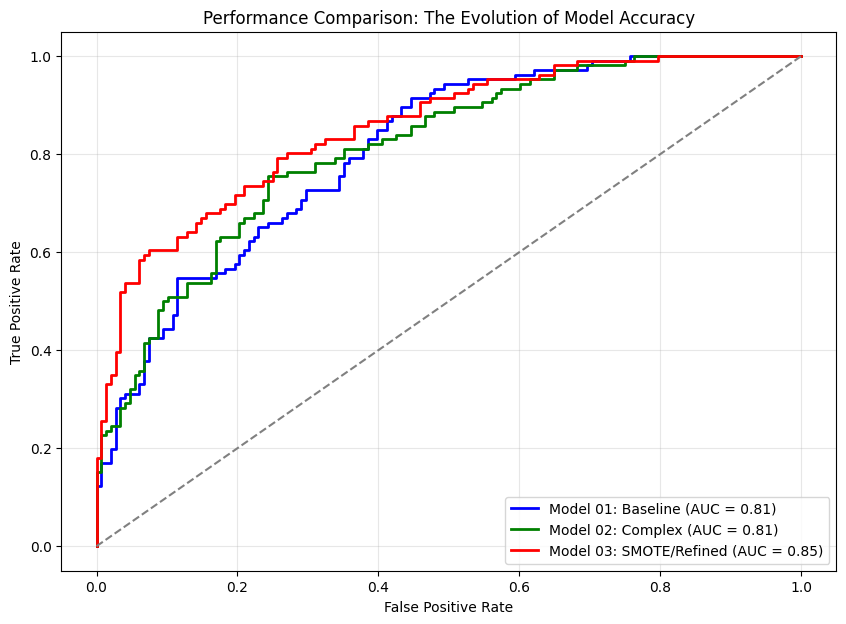

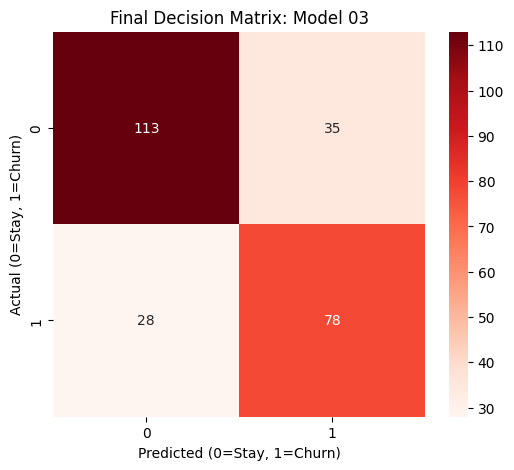


--- Model Performance Leaderboard ---
              Model   AUC  Recall  Accuracy
Model 01 (Baseline) 0.808   0.698     0.705
 Model 02 (Complex) 0.812   0.708     0.736
   Model 03 (SMOTE) 0.854   0.736     0.752


In [15]:
# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, recall_score, accuracy_score

# 1. GENERATE PREDICTIONS FOR ALL MODELS
# Note: Ensure you've run the training for all three models before this
probs_01 = model_01.predict(X_test)
probs_02 = model_02.predict(X_test)
probs_03 = model_03.predict(X_test_scaled) # Model 03 uses the SMOTE-scaled data

preds_03 = (probs_03 > 0.5).astype(int)

# 2. CREATE A 3-WAY ROC COMPARISON
plt.figure(figsize=(10, 7))

for probs, label, color in zip(
    [probs_01, probs_02, probs_03],
    ['Model 01: Baseline', 'Model 02: Complex', 'Model 03: SMOTE/Refined'],
    ['blue', 'green', 'red']
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Performance Comparison: The Evolution of Model Accuracy')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 3. FINAL CONFUSION MATRIX (For your best model - Model 03)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, preds_03)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Final Decision Matrix: Model 03')
plt.xlabel('Predicted (0=Stay, 1=Churn)')
plt.ylabel('Actual (0=Stay, 1=Churn)')
plt.show()

# 4. THE "LEADERBOARD" TABLE
results = []
for m_name, m_probs, m_preds in [
    ("Model 01 (Baseline)", probs_01, (probs_01 > 0.5).astype(int)),
    ("Model 02 (Complex)", probs_02, (probs_02 > 0.5).astype(int)),
    ("Model 03 (SMOTE)", probs_03, (probs_03 > 0.5).astype(int))
]:
    fpr, tpr, _ = roc_curve(y_test, m_probs)
    results.append({
        "Model": m_name,
        "AUC": round(auc(fpr, tpr), 3),
        "Recall": round(recall_score(y_test, m_preds), 3),
        "Accuracy": round(accuracy_score(y_test, m_preds), 3)
    })

print("\n--- Model Performance Leaderboard ---")
print(pd.DataFrame(results).to_string(index=False))